# Keras Aufbau: 

Input (128×128×3)

    > ↓ Conv2D(16) + ReLU + MaxPool
    > ↓ Conv2D(32) + ReLU + MaxPool
    > ↓ Conv2D(64) + ReLU + MaxPool
    > ↓ Conv2D(128) + ReLU + MaxPool
    > ↓ Flatten
    > ↓ Dense(2)

first conv() layer:

conv = Conv2D(
    filters=1,
    kernel_size=(3,3),
    use_bias=False,
    input_shape=(9,9,3)
)

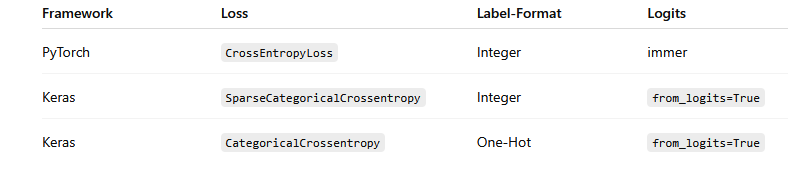


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense
# layers hat: Input, Conv2D, MaxPooling2D, Flatten, Dense

In [8]:
# ---------------------------------
# Daten
# ---------------------------------
X = np.random.randn(40, 128, 128, 3).astype(np.float32)  # 40 Bilder: n x h x w x c
y = np.random.randint(0, 2, size=(40,))                 # 2 Klassen

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (40, 128, 128, 3)
y shape: (40,)


In [10]:
model = Sequential([
    #input_shape=(128, 128, 3),
    Input(shape=(128, 128, 3)),
    Conv2D(16, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),      # 128 → 64

    Conv2D(32, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),      # 64 → 32

    Conv2D(64, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),      # 32 → 16

    Conv2D(128, (3, 3), padding="same", activation="relu"),
    MaxPooling2D((2, 2)),      # 16 → 8

    Flatten(),
    Dense(2)                   # out_c = 2 (Logits!)
])

## Modell kompilieren
⚠️ Wichtig:
Wir benutzen Logits, daher SparseCategoricalCrossentropy(from_logits=True)

→ genau wie CrossEntropyLoss in PyTorch


In [11]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        16,386 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 113,826 (444.63 KB)

 Trainable params: 113,826 (444.63 KB)

 Non-trainable params: 0 (0.00 B)

## Training (N Epochen, Mini-Batch = 4)

In [8]:
history = model.fit(
    X, y,
    epochs=30,
    batch_size=4,
    verbose=1
)

Epoch 1/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5250 - loss: 1.4932
Epoch 2/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5250 - loss: 0.7664
Epoch 3/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5250 - loss: 0.6880
Epoch 4/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.3750 - loss: 0.7019
Epoch 5/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5000 - loss: 0.6902
Epoch 6/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.6821
Epoch 7/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7000 - loss: 0.6634
Epoch 8/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5250 - loss: 0.6570
Epoch 9/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9000 - loss: 0.6246
Epoch 10/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8500 - loss: 0.5901
Epoch 11/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7250 - loss: 0.5786
Epoch 12/30
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8000 - lo

## Testlauf (Shape-Check)

In [9]:
x_test = np.random.randn(1, 128, 128, 3).astype(np.float32)
y_test = model(x_test)

print("Output shape:", y_test.shape)
print("Logits:", y_test.numpy())

Output shape: (1, 2)
Logits: [[-0.7424867  -0.25119543]]
